# Compound Options & Chooser Options

This notebook demonstrates two exotic option structures with multiple decision dates.

## Compound Options (Geske 1979)
An option on an option. The holder pays K₁ at T₁ to acquire an option (call or put) with strike K₂ expiring at T₂ > T₁.

Four types: **call-on-call (CoC)**, **put-on-call (PoC)**, **call-on-put (CoP)**, **put-on-put (PoP)**.

## Chooser Options (Rubinstein 1991)
At the choice date T_c, the holder decides whether the contract becomes a call or a put, both with the same strike K and expiry T > T_c.

**Reference**: Geske (1979), Rubinstein (1991), Haug (2007) Ch. 2.8.

In [1]:
import numpy as np
import matplotlib.pyplot as plt

from foureng.analytics.bsm_barrier import bsm_call, bsm_put
from foureng.analytics.bsm_compound import geske_compound_price
from foureng.analytics.bsm_chooser import bsm_chooser_price

# Base parameters
S, K2, r, q, T1, T2, sigma = 100.0, 100.0, 0.08, 0.0, 0.5, 1.0, 0.25

K1_vals = np.linspace(0, 20, 100)

print(f'Base: S={S}, K2={K2}, r={r}, q={q}, T1={T1}, T2={T2}, sigma={sigma}')
print()
vanilla_call = bsm_call(S, K2, r, q, T2, sigma)
vanilla_put  = bsm_put(S, K2, r, q, T2, sigma)
print(f'Vanilla call C(S,K2,T2): {vanilla_call:.4f}')
print(f'Vanilla put  P(S,K2,T2): {vanilla_put:.4f}')

Base: S=100.0, K2=100.0, r=0.08, q=0.0, T1=0.5, T2=1.0, sigma=0.25

Vanilla call C(S,K2,T2): 13.8922
Vanilla put  P(S,K2,T2): 6.2038


---
## 1. Compound Option Prices vs Outer Strike K₁

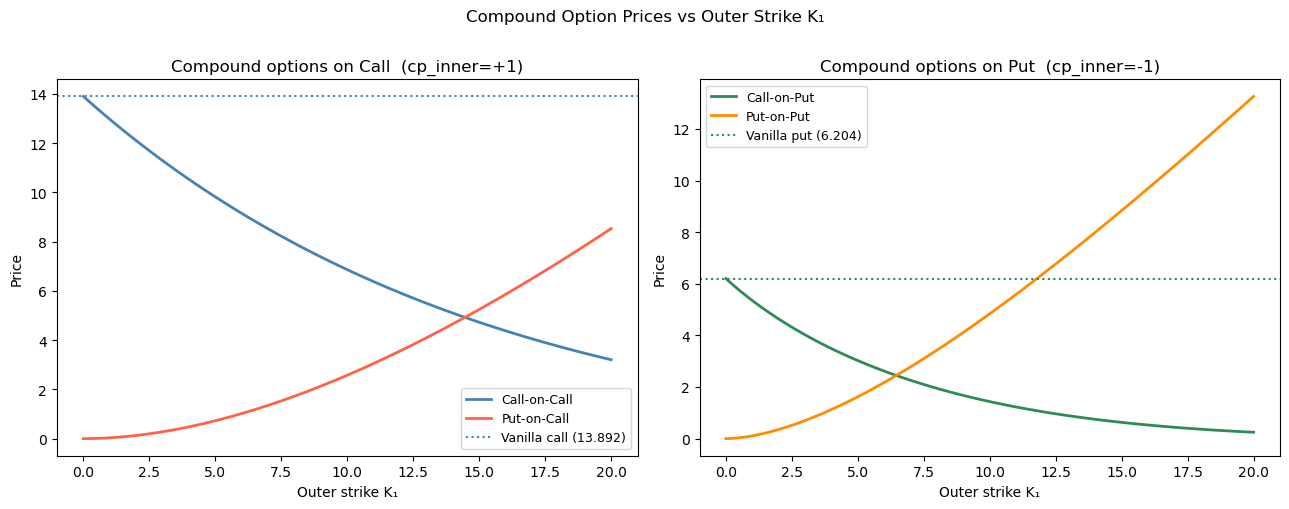

In [2]:
types = [
    (1,  1,  'Call-on-Call',  'steelblue'),
    (-1, 1,  'Put-on-Call',   'tomato'),
    (1,  -1, 'Call-on-Put',   'seagreen'),
    (-1, -1, 'Put-on-Put',    'darkorange'),
]

fig, axes = plt.subplots(1, 2, figsize=(13, 5))

for cp_o, cp_i, label, color in types:
    prices = [geske_compound_price(S, k1, K2, r, q, T1, T2, sigma, cp_o, cp_i)
              for k1 in K1_vals]
    ax = axes[0] if cp_i == 1 else axes[1]
    ax.plot(K1_vals, prices, label=label, color=color, lw=2)

axes[0].axhline(vanilla_call, color='steelblue', ls=':', lw=1.5, label=f'Vanilla call ({vanilla_call:.3f})')
axes[0].set_title('Compound options on Call  (cp_inner=+1)')
axes[0].set_xlabel('Outer strike K₁')
axes[0].set_ylabel('Price')
axes[0].legend(fontsize=9)

axes[1].axhline(vanilla_put, color='seagreen', ls=':', lw=1.5, label=f'Vanilla put ({vanilla_put:.3f})')
axes[1].set_title('Compound options on Put  (cp_inner=-1)')
axes[1].set_xlabel('Outer strike K₁')
axes[1].set_ylabel('Price')
axes[1].legend(fontsize=9)

plt.suptitle('Compound Option Prices vs Outer Strike K₁', y=1.01)
plt.tight_layout()
plt.show()

---
## 2. Put-Call Parity for Compound Options

Two exact compound option parity relations:

$$\text{CoC} - \text{PoC} = C(S, K_2, T_2) - K_1 e^{-rT_1}$$

$$\text{CoP} - \text{PoP} = P(S, K_2, T_2) - K_1 e^{-rT_1}$$

In [3]:
K1 = 5.0
CoC = geske_compound_price(S, K1, K2, r, q, T1, T2, sigma, 1, 1)
PoC = geske_compound_price(S, K1, K2, r, q, T1, T2, sigma, -1, 1)
CoP = geske_compound_price(S, K1, K2, r, q, T1, T2, sigma, 1, -1)
PoP = geske_compound_price(S, K1, K2, r, q, T1, T2, sigma, -1, -1)

disc_K1 = K1 * np.exp(-r * T1)

print(f'K₁ = {K1}  (disc K₁ = {disc_K1:.4f})')
print()
print(f'CoC = {CoC:.6f}    PoC = {PoC:.6f}')
print(f'CoC - PoC = {CoC - PoC:.6f}   vs   C(T2) - K1_disc = {vanilla_call - disc_K1:.6f}   error={abs(CoC-PoC-(vanilla_call-disc_K1)):.2e}')
print()
print(f'CoP = {CoP:.6f}    PoP = {PoP:.6f}')
print(f'CoP - PoP = {CoP - PoP:.6f}   vs   P(T2) - K1_disc = {vanilla_put - disc_K1:.6f}   error={abs(CoP-PoP-(vanilla_put-disc_K1)):.2e}')

K₁ = 5.0  (disc K₁ = 4.8039)

CoC = 9.814402    PoC = 0.726169
CoC - PoC = 9.088233   vs   C(T2) - K1_disc = 9.088233   error=3.55e-15

CoP = 3.022619    PoP = 1.622752
CoP - PoP = 1.399868   vs   P(T2) - K1_disc = 1.399868   error=1.60e-14


---
## 3. Compound Option vs Spot (S sweep)

CoC and PoC prices across moneyness, with K1=5 outer strike.

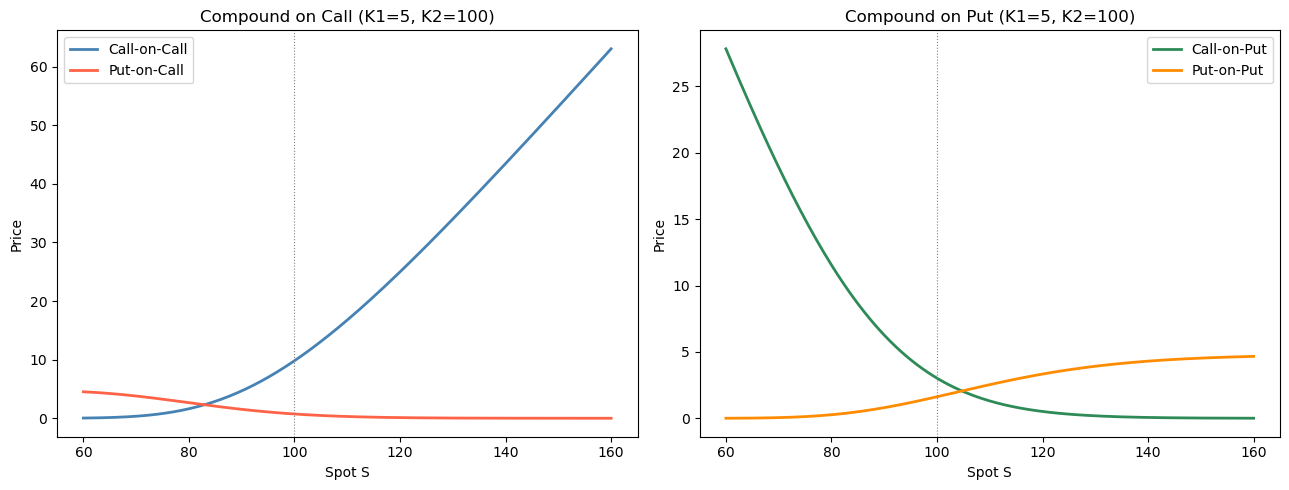

In [4]:
S_range = np.linspace(60, 160, 200)
K1_fixed = 5.0

coc_prices = [geske_compound_price(s, K1_fixed, K2, r, q, T1, T2, sigma, 1,  1) for s in S_range]
poc_prices = [geske_compound_price(s, K1_fixed, K2, r, q, T1, T2, sigma, -1, 1) for s in S_range]
cop_prices = [geske_compound_price(s, K1_fixed, K2, r, q, T1, T2, sigma, 1, -1) for s in S_range]
pop_prices = [geske_compound_price(s, K1_fixed, K2, r, q, T1, T2, sigma, -1,-1) for s in S_range]

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(13, 5))

ax1.plot(S_range, coc_prices, 'steelblue', lw=2, label='Call-on-Call')
ax1.plot(S_range, poc_prices, 'tomato',    lw=2, label='Put-on-Call')
ax1.axvline(K2, color='gray', lw=0.8, ls=':')
ax1.set_xlabel('Spot S'); ax1.set_ylabel('Price')
ax1.set_title('Compound on Call (K1=5, K2=100)')
ax1.legend()

ax2.plot(S_range, cop_prices, 'seagreen', lw=2, label='Call-on-Put')
ax2.plot(S_range, pop_prices, 'darkorange', lw=2, label='Put-on-Put')
ax2.axvline(K2, color='gray', lw=0.8, ls=':')
ax2.set_xlabel('Spot S'); ax2.set_ylabel('Price')
ax2.set_title('Compound on Put (K1=5, K2=100)')
ax2.legend()

plt.tight_layout()
plt.show()

---
## 4. Chooser Options — Introduction

### Rubinstein (1991) Decomposition

$$V_{\text{chooser}} = C(S, K^*, T_c, \sigma) + P(S, K, T_{\exp}, \sigma)$$

where $K^* = K \cdot e^{-(r-q)(T_{\exp} - T_c)}$.  

The chooser is worth **more** than either a pure call or pure put on the same terms — the extra value comes from the embedded choice.

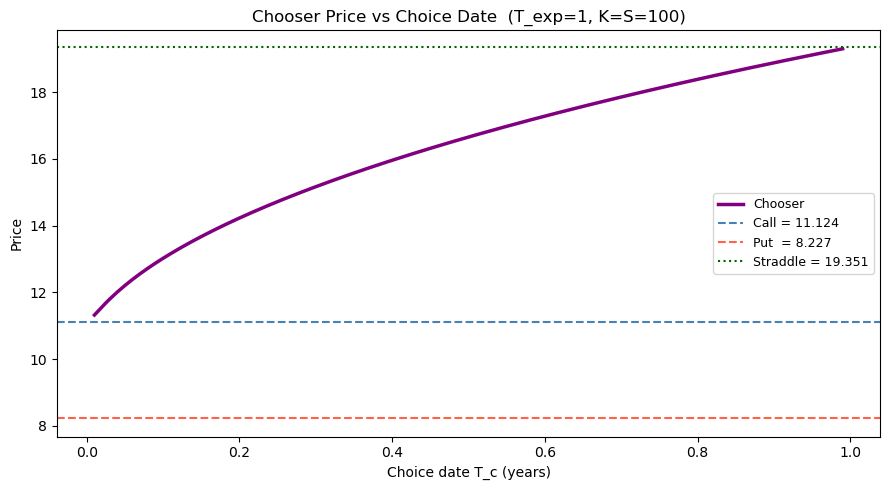

At T_c → 0: chooser approaches max(call, put) = 11.124
At T_c → T_exp: chooser approaches straddle = 19.351


In [5]:
S0, K_ch, r_ch, q_ch = 100.0, 100.0, 0.05, 0.02
T_exp_ch = 1.0
sigma_ch = 0.25

T_choice_range = np.linspace(0.01, T_exp_ch - 0.01, 200)
chooser_prices = [bsm_chooser_price(S0, K_ch, r_ch, q_ch, tc, T_exp_ch, sigma_ch)
                  for tc in T_choice_range]

call_price = bsm_call(S0, K_ch, r_ch, q_ch, T_exp_ch, sigma_ch)
put_price  = bsm_put(S0, K_ch, r_ch, q_ch, T_exp_ch, sigma_ch)
straddle   = call_price + put_price

fig, ax = plt.subplots(figsize=(9, 5))
ax.plot(T_choice_range, chooser_prices, 'purple', lw=2.5, label='Chooser')
ax.axhline(call_price, color='steelblue', ls='--', lw=1.5, label=f'Call = {call_price:.3f}')
ax.axhline(put_price,  color='tomato',    ls='--', lw=1.5, label=f'Put  = {put_price:.3f}')
ax.axhline(straddle,   color='darkgreen', ls=':',  lw=1.5, label=f'Straddle = {straddle:.3f}')
ax.set_xlabel('Choice date T_c (years)')
ax.set_ylabel('Price')
ax.set_title('Chooser Price vs Choice Date  (T_exp=1, K=S=100)')
ax.legend(fontsize=9)
plt.tight_layout()
plt.show()

print(f'At T_c → 0: chooser approaches max(call, put) = {max(call_price, put_price):.3f}')
print(f'At T_c → T_exp: chooser approaches straddle = {straddle:.3f}')

---
## 5. Chooser vs Spot (S sweep)

Compare chooser to vanilla call, put, and straddle across moneyness.

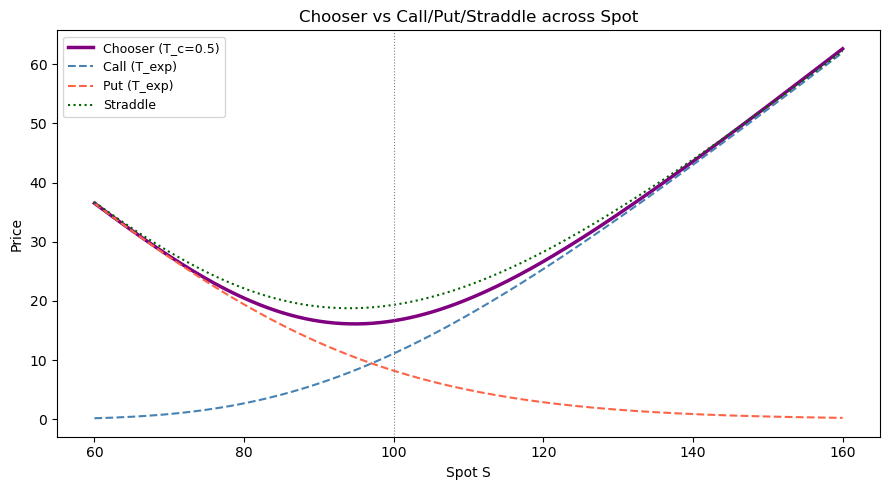

In [6]:
S_rng = np.linspace(60, 160, 200)
T_c = 0.5

ch_prices = [bsm_chooser_price(s, K_ch, r_ch, q_ch, T_c, T_exp_ch, sigma_ch) for s in S_rng]
call_prices = [bsm_call(s, K_ch, r_ch, q_ch, T_exp_ch, sigma_ch) for s in S_rng]
put_prices  = [bsm_put(s,  K_ch, r_ch, q_ch, T_exp_ch, sigma_ch) for s in S_rng]
straddle_prices = [c + p for c, p in zip(call_prices, put_prices)]

fig, ax = plt.subplots(figsize=(9, 5))
ax.plot(S_rng, ch_prices,       'purple',     lw=2.5, label=f'Chooser (T_c={T_c})')
ax.plot(S_rng, call_prices,     'steelblue',  lw=1.5, ls='--', label='Call (T_exp)')
ax.plot(S_rng, put_prices,      'tomato',     lw=1.5, ls='--', label='Put (T_exp)')
ax.plot(S_rng, straddle_prices, 'darkgreen',  lw=1.5, ls=':',  label='Straddle')
ax.axvline(K_ch, color='gray', lw=0.8, ls=':')
ax.set_xlabel('Spot S')
ax.set_ylabel('Price')
ax.set_title('Chooser vs Call/Put/Straddle across Spot')
ax.legend(fontsize=9)
plt.tight_layout()
plt.show()

---
## 6. Product dataclass usage

Both products integrate with the `foureng` pipeline via frozen dataclasses.

In [7]:
from foureng.products.compound import CompoundOption
from foureng.products.chooser import ChooserOption
from foureng.pipeline import price
from foureng.models.base import ForwardSpec
from foureng.models.bsm import BsmParams

# Compound: call-on-call
coc_product = CompoundOption(
    strike_outer=5.0, strike_inner=100.0,
    maturity_outer=0.5, maturity_inner=1.0,
    cp_outer=1, cp_inner=1,
)

# Chooser
chooser_product = ChooserOption(
    strike=100.0, maturity_choice=0.5, maturity_expiry=1.0
)

fwd = ForwardSpec(S0=100.0, r=0.08, q=0.0, T=1.0)
params = BsmParams(sigma=0.25)
fwd_ch = ForwardSpec(S0=100.0, r=0.05, q=0.02, T=1.0)
params_ch = BsmParams(sigma=0.25)

coc_price = price(coc_product, model='bsm', method='geske', fwd=fwd, params=params)
ch_price  = price(chooser_product, model='bsm', method='analytic', fwd=fwd_ch, params=params_ch)

print(f'CompoundOption (CoC): {coc_product}')
print(f'  Pipeline price: {coc_price:.6f}')
print()
print(f'ChooserOption: {chooser_product}')
print(f'  Pipeline price: {ch_price:.6f}')

CompoundOption (CoC): CompoundOption(strike_outer=5.0, strike_inner=100.0, maturity_outer=0.5, maturity_inner=1.0, cp_outer=1, cp_inner=1)
  Pipeline price: 9.814402

ChooserOption: ChooserOption(strike=100.0, maturity_choice=0.5, maturity_expiry=1.0)
  Pipeline price: 16.658357


---
## Summary

| Feature | Implementation |
|---------|----------------|
| `geske_compound_price` | Haug (2007) closed-form with four exact cases (CoC, PoC, CoP, PoP); bivariate normal CDF via `scipy.stats.multivariate_normal` |
| `bsm_chooser_price` | Rubinstein (1991) decomposition: call(K*, T_choice) + put(K, T_exp) |
| `CompoundOption` dataclass | Frozen, typed; validated T1 < T2 constraint |
| `ChooserOption` dataclass | Frozen, typed; validated T_choice < T_expiry constraint |
| Pipeline dispatch | `price(product, model='bsm', method='geske'/'analytic', ...)` |

**Key insights**:
- Compound option parity holds to machine precision: CoC − PoC = C(T₂) − K₁ e^{-rT₁}
- Chooser price is bounded: max(C, P) ≤ Chooser ≤ Straddle (C + P)
- Chooser approaches straddle as T_c → T_exp (no time to choose → choose everything)
- Compound options are cheaper than the underlying option and grow in value as S increases (for CoC)

**References**:
- Geske, R. (1979). The Valuation of Compound Options. *Journal of Financial Economics* 7(1), 63–81.
- Rubinstein, M. (1991). Double Trouble. *Risk Magazine* 4, 73.
- Haug, E.G. (2007). *The Complete Guide to Option Pricing Formulas*, 2nd ed., Ch. 2.8.